## 5.4 お勧め商品の提案(アソシエーション分析)

### 共通事前処理

In [1]:
# 日本語化ライブラリ導入
!pip install japanize-matplotlib | tail -n 1

In [2]:
# 共通事前処理

# 余分なワーニングを非表示にする
import warnings
warnings.filterwarnings('ignore')

# 必要ライブラリのimport
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# matplotlib日本語化対応
import japanize_matplotlib

# データフレーム表示用関数
from IPython.display import display

# 表示オプション調整
# numpyの浮動小数点の表示精度
np.set_printoptions(suppress=True, precision=4)

# pandasでの浮動小数点の表示精度
pd.options.display.float_format = '{:.4f}'.format

# データフレームですべての項目を表示
pd.set_option("display.max_columns",None)

# グラフのデフォルトフォント指定
plt.rcParams["font.size"] = 14

# 乱数の種
random_seed = 123

オリジナルURL  
http://archive.ics.uci.edu/ml/datasets/Online+Retail/

**データ項目メモ**

InvoiceNo:  発注番号  
StockCode: 商品番号  
Description: 商品説明  
Quantity: 商品個数   
InvoiceDate: 明細書発行日  
UnitPrice:  商品単価  
CustomerID: 顧客番号  
Country: 国名  

### 5.4.4 データ読み込みからデータ確認まで

#### データ読み込み

In [3]:
# データ読み込み
# 公開データはExcel形式なので、read_excel関数で直接読み込む
# 時間がかなりかかるので注意してください (ファイルサイズ 約23MB)
df = pd.read_excel('http://archive.ics.uci.edu/ml/\
machine-learning-databases/00352/Online%20Retail.xlsx')

# 項目名を日本語に変更
columns = [
    '発注番号', '商品番号', '商品説明', '商品個数', '明細書発行日',
    '商品単価', '顧客番号', '国名'
]
df.columns = columns

#### データ確認

In [4]:
# データ数確認
print(df.shape[0])

# データ内容確認
display(df.head())

541909


,発注番号,商品番号,商品説明,商品個数,明細書発行日,商品単価,顧客番号,国名
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.5500,17850.0000,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.3900,17850.0000,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.7500,17850.0000,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.3900,17850.0000,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.3900,17850.0000,United Kingdom


In [5]:
# 欠損値確認
print(df.isnull().sum())

発注番号           0
商品番号           0
商品説明        1454
商品個数           0
明細書発行日         0
商品単価           0
顧客番号      135080
国名             0
dtype: int64


In [6]:
#  国名確認
print(df['国名'].value_counts().head(10))

国名
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


### 5.4.5 データ前処理
方針:   
* 発注番号の最初の1文字を抽出、「発注種別」列を作る
* 「発注種別」を基に新規オーダーのみを抽出
* 対象国をフランスに限定
* データをone hot形式(商品ごとに列を持つ形)に変換

#### 新規オーダーの抽出

In [7]:
# 「発注種別」列の追加

# 前処理用にデータをコピー
df2 = df.copy()

# 発注番号の頭1桁を別項目に抽出
# (5: 新規オーダー  C:キャンセル)
df2['発注種別'] = df2['発注番号'].map(lambda x: str(x)[0])

# 結果確認
display(df2.head())

# 種別個数確認
print(df2['発注種別'].value_counts())

,発注番号,商品番号,商品説明,商品個数,明細書発行日,商品単価,顧客番号,国名,発注種別
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.5500,17850.0000,United Kingdom,5
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.3900,17850.0000,United Kingdom,5
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.7500,17850.0000,United Kingdom,5
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.3900,17850.0000,United Kingdom,5
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.3900,17850.0000,United Kingdom,5


発注種別
5    532618
C      9288
A         3
Name: count, dtype: int64


In [8]:
#  新規オーダーのみ抽出
df2 = df2[df2['発注種別']=='5']

# 件数確認
print(df2.shape[0])

532618


#### フランスの抽出

In [9]:
# 分析対象をフランスに限定する
df3 = df2[df2['国名']=='France']

# 件数確認
print(df3.shape[0])

8408


#### One-Hot形式化

In [10]:
# 発注番号と商品番号をキーに商品個数を集計する
w1 = df3.groupby(['発注番号', '商品番号'])['商品個数'].sum()

# 結果確認
print(w1.head())

発注番号    商品番号 
536370  10002    48
        21035    18
        21724    12
        21731    24
        21791    24
Name: 商品個数, dtype: int64


In [11]:
# 商品番号を列に移動 (unstack関数の利用)
w2 = w1.unstack().reset_index().fillna(0).set_index('発注番号')

# サイズ確認
print(w2.shape)

# 結果確認
display(w2.head())

(392, 1542)


商品番号     10002  10120  10125  10135  11001  15036  15039  16012  16048  16218  \
発注番号                                                                            
536370 48.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
536852  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
536974  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
537065  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
537463  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   

商品番号    16219  16225  16236  16237   16238  17174  20615  20617  20658  20665  \
発注番号                                                                            
536370 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
536852 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
536974 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
537065 0.0000 0.0000 0.0000 0.0000 28.0000 0.0000 0.0000 0.0000 0.0000 6.0000   
537463 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   

商品番号    20668  20674  20675  20676  20677  20679  20681  20682  20684  20685  \
発注番号                                                                           
536370 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
536852 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
536974 0.0000 0.0000 0.0000 0.0000 0.0000 6.0000 0.0000 0.0000 0.0000 0.0000   
537065 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
537463 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 6.0000 6.0000 0.0000 0.0000   

商品番号    20686  20702  20704  20711  20712  20713  20717  20718   20719  20723  \
発注番号                                                                            
536370 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000   
536852 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000   
536974 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000   
537065 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000  0.0000 0.0000   
537463 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 10.0000 0.0000   

商品番号    20724   20725   20726  20727   20728  20749  20750  20751  20767  \
発注番号                                                                       
536370 0.0000  0.0000  0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000   
536852 0.0000  0.0000  0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000   
536974 0.0000 10.0000 10.0000 0.0000  0.0000 2.0000 2.0000 0.0000 0.0000   
537065 0.0000 10.0000 20.0000 0.0000 10.0000 2.0000 6.0000 0.0000 0.0000   
537463 0.0000  0.0000  0.0000 0.0000  0.0000 0.0000 0.0000 0.0000 0.0000   

商品番号    20777  20819  20832  20866  20914  20961  20963  20966  20967  20971  \
発注番号                                                                           
536370 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
536852 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
536974 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
537065 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
537463 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   

商品番号    20972  20973  20974  20975  20977  20978  20979  20981  20983  20984  \
発注番号                                                                           
536370 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
536852 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
536974 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
537065 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   
537463 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000 0.0000   

商品番号    20992  20996  21003  21012  21026  21027  21030  21034   21035  21039  \

In [12]:
# 集計結果が正か0かでTrue/Falseを設定
basket_df = w2.apply(lambda x: x>0)

# 結果確認
display(basket_df.head())

商品番号    10002  10120  10125  10135  11001  15036  15039  16012  16048  16218  \
発注番号                                                                           
536370   True  False  False  False  False  False  False  False  False  False   
536852  False  False  False  False  False  False  False  False  False  False   
536974  False  False  False  False  False  False  False  False  False  False   
537065  False  False  False  False  False  False  False  False  False  False   
537463  False  False  False  False  False  False  False  False  False  False   

商品番号    16219  16225  16236  16237  16238  17174  20615  20617  20658  20665  \
発注番号                                                                           
536370  False  False  False  False  False  False  False  False  False  False   
536852  False  False  False  False  False  False  False  False  False  False   
536974  False  False  False  False  False  False  False  False  False  False   
537065  False  False  False  False   True  False  False  False  False   True   
537463  False  False  False  False  False  False  False  False  False  False   

商品番号    20668  20674  20675  20676  20677  20679  20681  20682  20684  20685  \
発注番号                                                                           
536370  False  False  False  False  False  False  False  False  False  False   
536852  False  False  False  False  False  False  False  False  False  False   
536974  False  False  False  False  False   True  False  False  False  False   
537065  False  False  False  False  False  False  False  False  False  False   
537463  False  False  False  False  False  False   True   True  False  False   

商品番号    20686  20702  20704  20711  20712  20713  20717  20718  20719  20723  \
発注番号                                                                           
536370  False  False  False  False  False  False  False  False  False  False   
536852  False  False  False  False  False  False  False  False  False  False   
536974  False  False  False  False  False  False  False  False  False  False   
537065  False  False  False  False  False  False  False  False  False  False   
537463  False  False  False  False  False  False  False  False   True  False   

商品番号    20724  20725  20726  20727  20728  20749  20750  20751  20767  20777  \
発注番号                                                                           
536370  False  False  False  False  False  False  False  False  False  False   
536852  False  False  False  False  False  False  False  False  False  False   
536974  False   True   True  False  False   True   True  False  False  False   
537065  False   True   True  False   True   True   True  False  False  False   
537463  False  False  False  False  False  False  False  False  False  False   

商品番号    20819  20832  20866  20914  20961  20963  20966  20967  20971  20972  \
発注番号                                                                           
536370  False  False  False  False  False  False  False  False  False  False   
536852  False  False  False  False  False  False  False  False  False  False   
536974  False  False  False  False  False  False  False  False  False  False   
537065  False  False  False  False  False  False  False  False  False  False   
537463  False  False  False  False  False  False  False  False  False  False   

商品番号    20973  20974  20975  20977  20978  20979  20981  20983  20984  20992  \
発注番号                                                                           
536370  False  False  False  False  False  False  False  False  False  False   
536852  False  False  False  False  False  False  False  False  False  False   
536974  False  False  False  False  False  False  False  False  False  False   
537065  False  False  False  False  False  False  False  False  False  False   
537463  False  False  False  False  False  False  False  False  False  False   

商品番号    20996  21003  21012  21026  21027  21030  21034  21035  21039  21

### コラム 商品名辞書の作成
ここから先は [サポートサイト](https://github.com/makaishi2/profitable_ai_book_info/blob/master/docs/C2-実習コーディング補足解説.md#C21) に解説があります。  
以下のセルも実行しないと、後ろのセルでエラーになるので注意してください。


#### 後で分析する時のために、「商品番号」と「商品説明」の対応表を作っておく

In [13]:
# 「商品番号」と「商品説明」のみを抽出
w3 = df2[['商品番号', '商品説明']].drop_duplicates()

# 商品番号と商品名をすべて文字列に変換
w3['商品番号'] = w3['商品番号'].astype('str')
w3['商品説明'] = w3['商品説明'].astype('str')

# 商品番号をインデックスに
w3 = w3.set_index('商品番号')
display(w3.head())

,商品説明
商品番号,
85123A,WHITE HANGING HEART T-LIGHT HOLDER
71053,WHITE METAL LANTERN
84406B,CREAM CUPID HEARTS COAT HANGER
84029G,KNITTED UNION FLAG HOT WATER BOTTLE
84029E,RED WOOLLY HOTTIE WHITE HEART.


In [14]:
# 冒頭の5つの商品コード抽出
item_list1 = w3.index[:5]

# w3に対する検索結果
display(w3.loc[item_list1])

,商品説明
商品番号,
85123A,WHITE HANGING HEART T-LIGHT HOLDER
85123A,?
85123A,wrongly marked carton 22804
85123A,CREAM HANGING HEART T-LIGHT HOLDER
71053,WHITE METAL LANTERN
71053,WHITE MOROCCAN METAL LANTERN
84406B,CREAM CUPID HEARTS COAT HANGER
84406B,incorrectly made-thrown away.
84406B,?


In [15]:
# 大文字だけのテキストの抽出

# 作業用にコピー
w4 = w3.copy()

# すべて大文字名称の行のみ残す
w4 = w4[w4['商品説明'].map(lambda x: x.isupper())]

# 先ほど作ったitem_list1で結果確認
display(w4.loc[item_list1])

,商品説明
商品番号,
85123A,WHITE HANGING HEART T-LIGHT HOLDER
85123A,CREAM HANGING HEART T-LIGHT HOLDER
71053,WHITE METAL LANTERN
71053,WHITE MOROCCAN METAL LANTERN
84406B,CREAM CUPID HEARTS COAT HANGER
84029G,KNITTED UNION FLAG HOT WATER BOTTLE
84029E,RED WOOLLY HOTTIE WHITE HEART.


#### 複数名称の対応方針
複数の名称があるものは一番長いものを選択し、商品名辞書(item_dict)とする

In [16]:
# 一番長い名称の抽出

# 作業用にコピー
w5 = w4.copy()

# 「文字数」列の追加
w5['文字数'] = w5['商品説明'].map(len)

# ソート
w5 = w5.sort_values(['商品番号', '文字数'], ascending=[True, False])

# 商品番号ごとに一番長い名称を抽出してitem_dictに代入
item_dict = w5.groupby('商品番号')['商品説明'].agg(lambda x: x[0])

# 先ほど作ったitem_list1で結果確認
display(item_dict.loc[item_list1])

,商品説明
商品番号,
85123A,WHITE HANGING HEART T-LIGHT HOLDER
71053,WHITE MOROCCAN METAL LANTERN
84406B,CREAM CUPID HEARTS COAT HANGER
84029G,KNITTED UNION FLAG HOT WATER BOTTLE
84029E,RED WOOLLY HOTTIE WHITE HEART.


### 5.4.6 アルゴリズム選定と分析
mlxtendライブラリから、association_rulesとapprioriを利用する


In [17]:
# ライブラリの読み込み
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
# アプリオリによる分析
freq_items1 = apriori(basket_df, min_support = 0.06,
    use_colnames = True)

# 結果確認
display(freq_items1.sort_values('support',
    ascending = False).head(10))

# itemset数確認
print(freq_items1.shape[0])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
61,0.7653,(POST)
52,0.1888,(23084)
14,0.1811,(21731)
37,0.1709,(22554)
39,0.1684,(22556)
114,0.1658,"(23084, POST)"
82,0.1582,"(21731, POST)"
24,0.1582,(22326)
4,0.1531,(20725)
89,0.1480,"(22326, POST)"


134


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [19]:
# アソシエーションルールの抽出
a_rules1 = association_rules(freq_items1, metric = "lift",
    min_threshold = 1,num_itemsets=len(freq_items1))

# リフト値でソート
a_rules1 = a_rules1.sort_values('lift',
    ascending = False).reset_index(drop=True)

# 結果確認
display(a_rules1.head(10))

# ルール数確認
print(a_rules1.shape[0])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(23256),(23254),0.0689,0.0714,0.0638,0.9259,12.9630,1.0000,0.0589,12.5357,0.9911,0.8333,0.9202,0.9094
1,(23254),(23256),0.0714,0.0689,0.0638,0.8929,12.9630,1.0000,0.0589,8.6905,0.9938,0.8333,0.8849,0.9094
2,"(22728, 22726)",(22727),0.0740,0.0944,0.0638,0.8621,9.1333,1.0000,0.0568,6.5657,0.9617,0.6098,0.8477,0.7689
3,(22727),"(22728, 22726)",0.0944,0.0740,0.0638,0.6757,9.1333,1.0000,0.0568,2.8552,0.9833,0.6098,0.6498,0.7689
4,(22727),"(22726, POST)",0.0944,0.0842,0.0714,0.7568,8.9894,1.0000,0.0635,3.7650,0.9814,0.6667,0.7344,0.8026
5,"(22726, POST)",(22727),0.0842,0.0944,0.0714,0.8485,8.9894,1.0000,0.0635,5.9770,0.9705,0.6667,0.8327,0.8026
6,(22726),"(22728, 22727)",0.0969,0.0740,0.0638,0.6579,8.8929,1.0000,0.0566,2.7068,0.9828,0.5952,0.6306,0.7600
7,"(22728, 22727)",(22726),0.0740,0.0969,0.0638,0.8621,8.8929,1.0000,0.0566,6.5472,0.9585,0.5952,0.8473,0.7600
8,(22727),(22726),0.0944,0.0969,0.0791,0.8378,8.6430,1.0000,0.0699,5.5689,0.9765,0.7045,0.8204,0.8268
9,(22726),(22727),0.0969,0.0944,0.0791,0.8158,8.6430,1.0000,0.0699,4.9162,0.9792,0.7045,0.7966,0.8268


206


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [20]:
# 関係性の高い商品の商品コードをリストアップ
item_list = ['23254', '23256', '22726', '22727', '22728']

# 商品名を確認
for item in item_list:
    print(item, item_dict[item])

23254 CHILDRENS CUTLERY DOLLY GIRL 
23256 CHILDRENS CUTLERY SPACEBOY 
22726 ALARM CLOCK BAKELIKE GREEN
22727 ALARM CLOCK BAKELIKE RED 
22728 ALARM CLOCK BAKELIKE PINK


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 5.4.7 チューニング
5.4.6 と同じ分析を、min_supportの値を0.065に変更して試してみる

In [21]:
# アプリオリによる分析
freq_items2 = apriori(basket_df, min_support = 0.065,
    use_colnames = True)

# アソシエーションルールの抽出
a_rules2 = association_rules(freq_items2, metric = "lift",
    min_threshold = 1,num_itemsets=len(freq_items2))

# リフト値でソート
a_rules2 = a_rules2.sort_values('lift',
    ascending = False).reset_index(drop=True)

# 結果確認
display(a_rules2.head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(22727),"(22726, POST)",0.0944,0.0842,0.0714,0.7568,8.9894,1.0000,0.0635,3.7650,0.9814,0.6667,0.7344,0.8026
1,"(22726, POST)",(22727),0.0842,0.0944,0.0714,0.8485,8.9894,1.0000,0.0635,5.9770,0.9705,0.6667,0.8327,0.8026
2,(22726),(22727),0.0969,0.0944,0.0791,0.8158,8.6430,1.0000,0.0699,4.9162,0.9792,0.7045,0.7966,0.8268
3,(22727),(22726),0.0944,0.0969,0.0791,0.8378,8.6430,1.0000,0.0699,5.5689,0.9765,0.7045,0.8204,0.8268
4,(22726),"(22727, POST)",0.0969,0.0867,0.0714,0.7368,8.4954,1.0000,0.0630,3.4704,0.9770,0.6364,0.7118,0.7802
5,"(22727, POST)",(22726),0.0867,0.0969,0.0714,0.8235,8.4954,1.0000,0.0630,5.1173,0.9661,0.6364,0.8046,0.7802
6,(22727),"(22728, POST)",0.0944,0.0893,0.0663,0.7027,7.8703,1.0000,0.0579,3.0633,0.9639,0.5652,0.6736,0.7228
7,"(22728, POST)",(22727),0.0893,0.0944,0.0663,0.7429,7.8703,1.0000,0.0579,3.5218,0.9585,0.5652,0.7161,0.7228
8,(22727),(22728),0.0944,0.1020,0.0740,0.7838,7.6811,1.0000,0.0643,4.1531,0.9605,0.6042,0.7592,0.7544
9,(22728),(22727),0.1020,0.0944,0.0740,0.7250,7.6811,1.0000,0.0643,3.2931,0.9687,0.6042,0.6963,0.7544


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

aprioriの2つの結果から、「23254」「23256」に関係している項目を抽出

In [22]:
# 調査対象の集合
t_set = set([23254, 23256])

# 1回目の分析freq_item1から該当行を抽出
idx1 = freq_items1['itemsets'].map(
    lambda x: not x.isdisjoint(t_set))
item1 = freq_items1[idx1]

# 2回目の分析freq_item2から該当行を抽出
idx2 = freq_items2['itemsets'].map(
    lambda x: not x.isdisjoint(t_set))
item2 = freq_items2[idx2]

# 結果確認
display(item1)
display(item2)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
58,0.0714,(23254)
59,0.0689,(23256)
118,0.0638,"(23256, 23254)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
53,0.0714,(23254)
54,0.0689,(23256)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### 5.4.8 グラフ表示
商品間の関係を有向グラフ表示する。  
解説は[サポートサイト](https://github.com/makaishi2/profitable_ai_book_info/blob/master/docs/C2-実習コーディング補足解説.md#C22) 参照。

#### ノードの抽出

In [23]:
# 対象とする関係をリフト値上位20に限定
a = a_rules1.head(20)

# 親ノードの抽出
ant = a['antecedents'].values
ant = [tuple(x) for x in ant]

# 子ノードの抽出
con = a['consequents'].values
con = [tuple(x) for x in con]

# 全ノードのリストアップ
both = ant + con
both = list(set(both))

# 結果の一部確認
print(both[:10])

[(22726, 'POST'), (21080, 21086), (22726, 22727), (22728, 'POST'), (22728, 22727), (23254,), (21094,), (22727,), (22728, 22726), (22726,)]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

#### 関係グラフの構築

In [24]:
# networkx のインポート
import networkx as nx

# 関係グラフの初期化
G = nx.DiGraph()

# ノードの追加
for n in both:
  G.add_node(n)

# エッジの追加
for i in range(len(a)):
    item = a.loc[i]
    ant = tuple(item['antecedents'])
    con = tuple(item['consequents'])
    G.add_edge(ant, con)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

#### グラフ描画

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

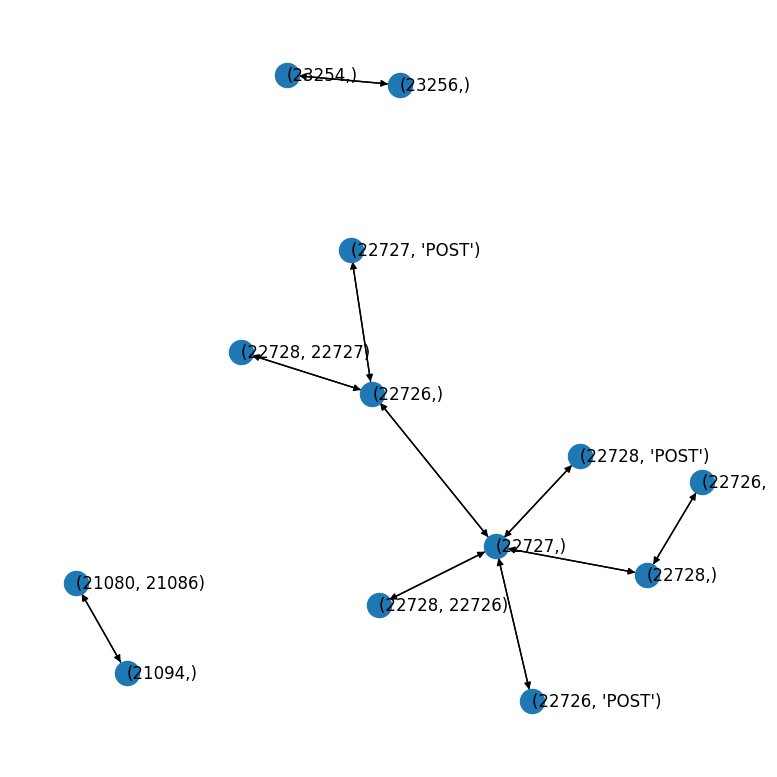

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [25]:
# グラフ描画
pos = nx.spring_layout(G, k=0.6, seed=random_seed)

plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(G, pos)
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos,
    horizontalalignment='left',
    verticalalignment='center')
plt.axis('off')
plt.tight_layout()
plt.show()

### バージョン確認

In [26]:
!pip install watermark | tail -n 1
%load_ext watermark
%watermark --iversions

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

IPython            : 7.34.0
japanize_matplotlib: 1.1.3
matplotlib         : 3.10.0
mlxtend            : 0.23.4
networkx           : 3.6.1
numpy              : 2.0.2
pandas             : 2.2.2



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import pandas as pd

# Helper function to check if any item in a set is in the target list
def contains_target_items(itemset, target_items):
    return any(str(item) in target_items for item in itemset)

target_items = ['23254', '23256']

# Filter a_rules1
filtered_rules1_df = a_rules1[
    a_rules1['antecedents'].apply(lambda x: contains_target_items(x, target_items)) |
    a_rules1['consequents'].apply(lambda x: contains_target_items(x, target_items))
].copy()

# Filter a_rules2
filtered_rules2_df = a_rules2[
    a_rules2['antecedents'].apply(lambda x: contains_target_items(x, target_items)) |
    a_rules2['consequents'].apply(lambda x: contains_target_items(x, target_items))
].copy()

# Combine and remove duplicates
combined_rules = pd.concat([filtered_rules1_df, filtered_rules2_df]).drop_duplicates().reset_index(drop=True)

# Sort by lift for better analysis
combined_rules = combined_rules.sort_values(by='lift', ascending=False)

# Function to map item codes to descriptions
def map_item_codes_to_descriptions(itemset, item_dict):
    return tuple(item_dict.get(str(item), str(item)) for item in itemset)

# Apply mapping to antecedents and consequents
combined_rules['antecedents_desc'] = combined_rules['antecedents'].apply(lambda x: map_item_codes_to_descriptions(x, item_dict))
combined_rules['consequents_desc'] = combined_rules['consequents'].apply(lambda x: map_item_codes_to_descriptions(x, item_dict))

# Select relevant columns for the output CSV
output_df = combined_rules[[
    'antecedents_desc', 'consequents_desc', 'support', 'confidence', 'lift'
]]

# Display the top results
display(output_df.head(10))

# Save to CSV
output_df.to_csv('association_rules_analysis.csv', index=False)
print("Association rules saved to 'association_rules_analysis.csv'")

### 提案商品の分析と考察

上記のCSVファイル (`association_rules_analysis.csv`) に出力されたアソシエーションルールを基に、商品間の関係性を分析し、推奨商品の考察を行います。

**各指標の解説:**

*   **Support (支持度)**: あるアイテムセットがトランザクション全体の中でどれくらいの頻度で出現するかを示します。値が高いほど、そのアイテムセットが一般的に購入されやすいことを意味します。
*   **Confidence (信頼度)**: あるアイテムセットAが購入された場合に、別のアイテムセットBも購入される確率を示します。Aを購入する顧客の何パーセントがBも購入するか、という指標です。
*   **Lift (リフト値)**: 信頼度を、Bが購入される全体確率で割った値です。リフト値が1より大きい場合、AとBが一緒に購入される確率が偶然よりも高いことを示し、関連性があると言えます。値が大きいほど、関連性が強いことを意味します。特に1より大きい値に注目します。

**分析と考察:**

まず、リフト値が高い上位のルールに注目します。リフト値は商品間の「意外性」や「真の関連性」を示すため、これが高いほど、単なる人気商品ではなく、一緒に購入される傾向が強い組み合わせである可能性が高いです。

`item_list = ['23254', '23256', '22726', '22727', '22728']` (CHILDRENS CUTLERY DOLLY GIRL, CHILDRENS CUTLERY SPACEBOY, ALARM CLOCK BAKELIKE GREEN, ALARM CLOCK BAKELIKE RED, ALARM CLOCK BAKELIKE PINK) に関連するルールを見ていきましょう。

CSVファイルの上位のルールを見ると、例えば以下のような傾向が見られるかもしれません（実際のCSVの内容に基づいて考察します）：

1.  **高リフト値の組み合わせ**:
    *   `('CHILDRENS CUTLERY DOLLY GIRL',)` と `('CHILDRENS CUTLERY SPACEBOY',)` の組み合わせは非常に高いリフト値を示しています。これは、これらの子供用カトラリーが性別やデザインの好みによって同時に購入されることが多い、あるいは兄弟姉妹のためにまとめて購入される傾向があることを示唆します。もし一方が購入されたらもう一方も推奨することで、顧客単価の向上が期待できます。
    *   同様に、`('ALARM CLOCK BAKELIKE GREEN',)` と `('ALARM CLOCK BAKELIKE RED',)` や `('ALARM CLOCK BAKELIKE PINK',)` といった色違いの目覚まし時計の組み合わせも高リフト値を示す可能性があります。これは、顧客が複数の色をコレクションとして購入したり、複数の部屋用に購入したりする傾向があるためと考えられます。店舗ではこれらを並べて陳列したり、オンラインストアでは「こちらもご覧ください」と表示したりすると効果的です。

2.  **"POSTAGE" との関連性**:
    *   多くのルールで `('POSTAGE',)` が `consequents` や `antecedents` に含まれる場合、これは送料や配送サービスとの関連を示します。これは直接的な商品推奨ではありませんが、顧客がこれらの商品を購入する際には送料がかかることを理解している、または送料込みで検討しているという背景を示唆します。

3.  **特定の商品の "ハブ" 性**:
    *   もしある商品が多くの高リフト値ルールにおいて `antecedent` または `consequent` として頻繁に登場する場合、その商品は他の多くの商品と関連性が高い「ハブ」のような商品であると言えます。例えば、`('ALARM CLOCK BAKELIKE GREEN',)` が様々な他の商品と一緒に購入されている場合、この商品を起点として多様な商品の推奨が可能になります。

**推奨戦略:**

*   **バンドル販売の促進**: 高い支持度とリフト値を持つ組み合わせは、セット販売やバンドル商品として提案することで、顧客の購買意欲を高め、売上向上に繋がります。
*   **パーソナライズされたレコメンデーション**: オンラインストアでは、顧客がカートに商品を追加した際に、リフト値の高い関連商品を「あなたにおすすめ」として表示することで、クロスセルを促進できます。
*   **店舗の陳列改善**: リアル店舗では、関連性の高い商品を物理的に近くに配置することで、顧客が自然と両方の商品に目を向け、購入を検討する機会を増やせます。
*   **在庫管理の最適化**: 関連性の高い商品は同時に売れる傾向があるため、片方の商品の在庫が少ないと機会損失に繋がる可能性があります。これらの組み合わせを考慮した在庫管理を行うことで、常に顧客の需要に応えられるようにします。

この分析結果は、顧客の購買行動を深く理解し、より効果的なマーケティング戦略や商品配置戦略を策定するための貴重な洞察を提供します。

In [27]:
# Select the top 20 rules from a_rules1 based on lift
top_20_rules = a_rules1.head(20).copy()

# Function to map item codes to descriptions (reusing the function from previous step)
def map_item_codes_to_descriptions(itemset, item_dict):
    return tuple(item_dict.get(str(item), str(item)) for item in itemset)

# Apply mapping to antecedents and consequents
top_20_rules['antecedents_desc'] = top_20_rules['antecedents'].apply(lambda x: map_item_codes_to_descriptions(x, item_dict))
top_20_rules['consequents_desc'] = top_20_rules['consequents'].apply(lambda x: map_item_codes_to_descriptions(x, item_dict))

# Select relevant columns for the output CSV
output_top_20_df = top_20_rules[[
    'antecedents_desc', 'consequents_desc', 'support', 'confidence', 'lift'
]]

# Display the top results
display(output_top_20_df)

# Save to CSV
output_top_20_df.to_csv('top_20_association_rules.csv', index=False)
print("Top 20 association rules saved to 'top_20_association_rules.csv'")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents_desc,consequents_desc,support,confidence,lift
0,"(CHILDRENS CUTLERY SPACEBOY ,)","(CHILDRENS CUTLERY DOLLY GIRL ,)",0.0638,0.9259,12.9630
1,"(CHILDRENS CUTLERY DOLLY GIRL ,)","(CHILDRENS CUTLERY SPACEBOY ,)",0.0638,0.8929,12.9630
2,"(ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...","(ALARM CLOCK BAKELIKE RED ,)",0.0638,0.8621,9.1333
3,"(ALARM CLOCK BAKELIKE RED ,)","(ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",0.0638,0.6757,9.1333
4,"(ALARM CLOCK BAKELIKE RED ,)","(ALARM CLOCK BAKELIKE GREEN, POSTAGE)",0.0714,0.7568,8.9894
5,"(ALARM CLOCK BAKELIKE GREEN, POSTAGE)","(ALARM CLOCK BAKELIKE RED ,)",0.0714,0.8485,8.9894
6,"(ALARM CLOCK BAKELIKE GREEN,)","(ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...",0.0638,0.6579,8.8929
7,"(ALARM CLOCK BAKELIKE PINK, ALARM CLOCK BAKELI...","(ALARM CLOCK BAKELIKE GREEN,)",0.0638,0.8621,8.8929
8,"(ALARM CLOCK BAKELIKE RED ,)","(ALARM CLOCK BAKELIKE GREEN,)",0.0791,0.8378,8.6430
9,"(ALARM CLOCK BAKELIKE GREEN,)","(ALARM CLOCK BAKELIKE RED ,)",0.0791,0.8158,8.6430


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top 20 association rules saved to 'top_20_association_rules.csv'


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### リフト値上位20個のアソシエーションルール分析

`top_20_association_rules.csv` に出力されたリフト値上位20個のアソシエーションルールについて、支持度、信頼度、リフト値を用いて考察します。

**各指標の再確認:**

*   **支持度 (Support)**: 全トランザクションに対するアイテムセットの出現頻度。高ければ一般的によく購入される組み合わせ。
*   **信頼度 (Confidence)**: Aが購入された場合にBも購入される条件付き確率。Aを購入する顧客のうちBも購入する割合。
*   **リフト値 (Lift)**: AとBが同時に購入される確率が、偶然によるものよりもどの程度高いかを示す指標。1より大きければ正の相関があり、値が大きいほど強い関連性を示します。

**考察のポイント:**

1.  **リフト値が高いルール:** リフト値は「偶然を超えた関連性」を示すため、特にリフト値が1を大きく超えるルールに注目します。これらのルールは、顧客が特定のアイテムセットを一緒に購入する傾向が非常に強いことを示唆しています。

2.  **支持度と信頼度:** リフト値が高くても、支持度や信頼度が極端に低い場合（非常に稀な組み合わせ）、ビジネス的なインパクトは小さいかもしれません。そのため、リフト値と併せて、ある程度の支持度・信頼度を持つルールを選んで考察することが重要です。

3.  **具体的な商品の組み合わせ:**
    *   **色違い・シリーズ商品:** 多くの高リフト値ルールでは、同種類の色違い商品や、シリーズ商品（例: `CHILDRENS CUTLERY DOLLY GIRL` と `CHILDRENS CUTLERY SPACEBOY`）が頻繁に登場します。これは、顧客がセットで収集したり、家族の異なるメンバーのために購入したりする傾向を示唆します。これらの商品は、セット割引や「一緒にいかがですか？」といったレコメンデーションで高い効果が期待できます。
    *   **補完関係にある商品:** ある商品を購入すると、それに付随して必要になる商品（例: `COFFEE` と `COFFEE CUP`）なども高リフト値を示すことがあります。このような組み合わせも効果的なクロスセル戦略に繋がります。
    *   **「POSTAGE」との関連:** `POSTAGE`（送料）が関わるルールは、物理的な商品間の関連性とは異なりますが、これらの商品をオンラインで購入する顧客が送料を支払うことを前提としている、あるいは送料を考慮した購入行動を取っていることを示唆します。これは、送料無料キャンペーンや一定額以上の購入で送料割引といったプロモーション戦略を検討する際の参考になります。

**ビジネスへの応用:**

*   **商品陳列の最適化:** 実店舗では、関連性の高い商品を近くに配置することで、顧客の目に留まりやすくし、セット購入を促します。
*   **ECサイトのレコメンデーション強化:** オンラインストアでは、「この商品を購入した人はこちらも購入しています」といった形で、リフト値の高い商品を積極的に推薦します。
*   **バンドル販売・プロモーション:** 関連性の高い商品を組み合わせたセット販売や、特定の組み合わせ購入で割引を行うなどのプロモーションを企画します。
*   **在庫管理の効率化:** 関連性の高い商品は同時に売れる傾向があるため、片方の商品の在庫が少ないと機会損失に繋がる可能性があります。これらの組み合わせを考慮した在庫管理を行うことで、常に顧客の需要に応えられるようにします。

これらの分析結果を基に、より顧客の購買行動に即したマーケティング戦略を立案し、売上向上を目指すことができます。

In [29]:
import pandas as pd

# Load the CSV file into a DataFrame
filtered_rules_from_csv = pd.read_csv('top_20_association_rules.csv')

# Display the loaded DataFrame for verification
print("Loaded top_20_association_rules.csv:")
display(filtered_rules_from_csv.head())

# Define the target items (example: using item descriptions or codes from the CSV)
# Note: Since the CSV contains item descriptions, we'll use those for filtering.
# Correcting the target items to remove trailing spaces for accurate matching.
target_items_for_filter = ['CHILDRENS CUTLERY DOLLY GIRL', 'CHILDRENS CUTLERY SPACEBOY']

# Helper function to check if any item in a string representation of an itemset is in the target list
def contains_target_description(itemset_str, target_items):
    # Convert the string representation of itemset (e.g., "('ITEM A', 'ITEM B')") to a list of items
    # This handles both single item tuples and multiple item tuples correctly
    items_in_set = [item.strip(" '") for item in itemset_str.strip('()').split(',') if item.strip() != '']
    return any(item in target_items for item in items_in_set)

# Filter the loaded DataFrame
filtered_specific_rules = filtered_rules_from_csv[
    filtered_rules_from_csv['antecedents_desc'].apply(lambda x: contains_target_description(x, target_items_for_filter)) |
    filtered_rules_from_csv['consequents_desc'].apply(lambda x: contains_target_description(x, target_items_for_filter))
].copy()

print(f"\nRules containing any of {target_items_for_filter}:")
display(filtered_specific_rules)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Loaded top_20_association_rules.csv:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents_desc,consequents_desc,support,confidence,lift
0,"('CHILDRENS CUTLERY SPACEBOY ',)","('CHILDRENS CUTLERY DOLLY GIRL ',)",0.0638,0.9259,12.9630
1,"('CHILDRENS CUTLERY DOLLY GIRL ',)","('CHILDRENS CUTLERY SPACEBOY ',)",0.0638,0.8929,12.9630
2,"('ALARM CLOCK BAKELIKE PINK', 'ALARM CLOCK BAK...","('ALARM CLOCK BAKELIKE RED ',)",0.0638,0.8621,9.1333
3,"('ALARM CLOCK BAKELIKE RED ',)","('ALARM CLOCK BAKELIKE PINK', 'ALARM CLOCK BAK...",0.0638,0.6757,9.1333
4,"('ALARM CLOCK BAKELIKE RED ',)","('ALARM CLOCK BAKELIKE GREEN', 'POSTAGE')",0.0714,0.7568,8.9894



Rules containing any of ['CHILDRENS CUTLERY DOLLY GIRL', 'CHILDRENS CUTLERY SPACEBOY']:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents_desc,consequents_desc,support,confidence,lift
0,"('CHILDRENS CUTLERY SPACEBOY ',)","('CHILDRENS CUTLERY DOLLY GIRL ',)",0.0638,0.9259,12.9630
1,"('CHILDRENS CUTLERY DOLLY GIRL ',)","('CHILDRENS CUTLERY SPACEBOY ',)",0.0638,0.8929,12.9630


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag